<a href="https://colab.research.google.com/github/SatyaUdisi/Titanic-Data-Cleaning-Project-task3/blob/main/predictive_modeling_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model Test Accuracy: 0.8045

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



<Figure size 600x500 with 0 Axes>

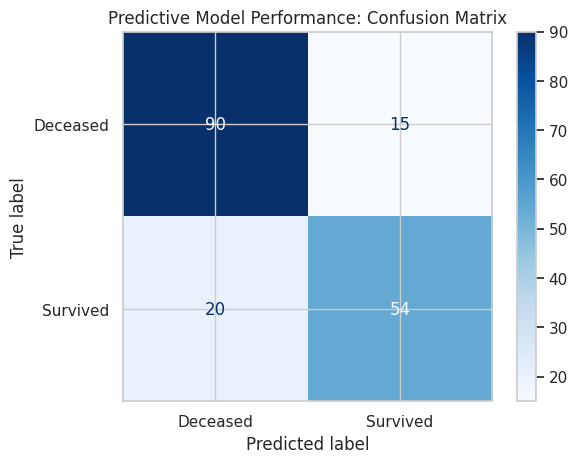

Machine learning pipeline execution complete!


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ==========================================
# 1. LOAD & PREPROCESS DATA (From your previous project)
# ==========================================
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Quick preprocessing
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Convert categorical features (Sex) into numerical values
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Select features (X) and target variable (y)
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features]
y = df['Survived']

# ==========================================
# 2. TRAIN-TEST SPLIT
# ==========================================
# Splitting 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 3. APPLY ALGORITHM (Random Forest Classifier)
# ==========================================
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on test data
y_pred = model.predict(X_test)

# ==========================================
# 4. EVALUATE ACCURACY
# ==========================================
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Test Accuracy: {accuracy:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

# ==========================================
# 5. VISUALIZE PERFORMANCE (Confusion Matrix)
# ==========================================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Deceased', 'Survived'])

# Plotting the matrix
plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d')
plt.title('Predictive Model Performance: Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Machine learning pipeline execution complete!")